# Toán tử điểm ảnh

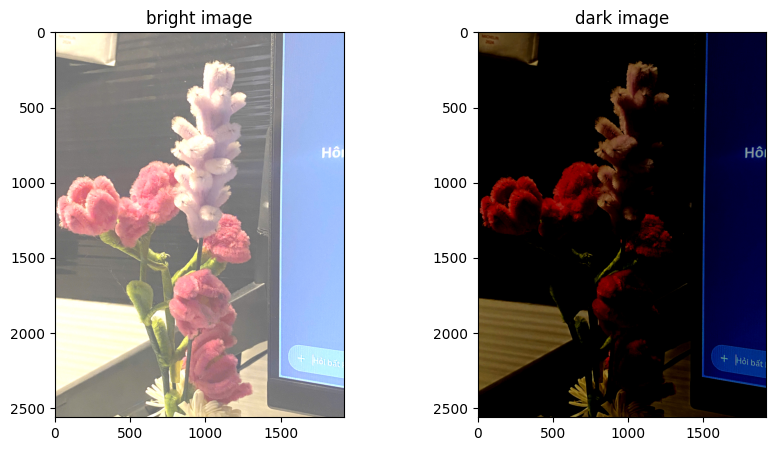

In [8]:
# Thay đổi độ sáng
import numpy as np
import cv2 
import matplotlib.pyplot as plt

img = cv2.imread("/home/tuong/Courses/CV/opencv-learning/flower_new.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
bright_img = cv2.add(img_rgb, 100.0)
dark_img = cv2.subtract(img_rgb, 100.0)

plt.figure(figsize= (10,5))
plt.subplot(121)
plt.imshow(bright_img)
plt.title("bright image")

plt.subplot(122)
plt.imshow(dark_img)
plt.title("dark image")
plt.show()



In [9]:
print(img_rgb)
print("======")
print(bright_img)

[[[196 175 128]
  [196 175 128]
  [196 175 128]
  ...
  [ 58  89 146]
  [ 58  89 146]
  [ 58  89 146]]

 [[197 176 129]
  [197 176 129]
  [197 176 129]
  ...
  [ 59  90 147]
  [ 60  91 148]
  [ 60  91 148]]

 [[197 176 129]
  [197 176 129]
  [197 176 129]
  ...
  [ 61  92 149]
  [ 62  93 150]
  [ 62  93 150]]

 ...

 [[ 44  41  24]
  [ 45  42  27]
  [ 45  42  27]
  ...
  [ 20  19  24]
  [ 21  20  25]
  [ 22  21  26]]

 [[ 45  42  25]
  [ 44  41  26]
  [ 44  41  26]
  ...
  [ 21  20  25]
  [ 22  21  26]
  [ 22  21  26]]

 [[ 45  42  25]
  [ 44  41  26]
  [ 44  41  26]
  ...
  [ 22  21  26]
  [ 24  23  28]
  [ 24  23  28]]]
[[[255 255 228]
  [255 255 228]
  [255 255 228]
  ...
  [158 189 246]
  [158 189 246]
  [158 189 246]]

 [[255 255 229]
  [255 255 229]
  [255 255 229]
  ...
  [159 190 247]
  [160 191 248]
  [160 191 248]]

 [[255 255 229]
  [255 255 229]
  [255 255 229]
  ...
  [161 192 249]
  [162 193 250]
  [162 193 250]]

 ...

 [[144 141 124]
  [145 142 127]
  [145 142 127]
  ..

# Thay đổi độ tương phản (Contrast)

### Độ tương phản là sự khác biệt giữa vùng sáng và vùng tối. Ta thực hiện bằng cách nhân điểm ảnh với một hệ số $\alpha$.
### $\alpha > 1$: Tăng tương phản (vùng sáng sáng hơn, vùng tối tối hơn).$0 < \alpha < 1$: Giảm tương phản (ảnh trông xám xịt, bạc màu).

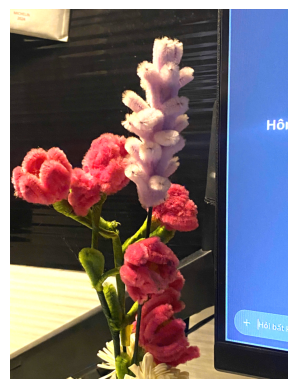

In [12]:
constrast_img = cv2.convertScaleAbs(img_rgb, alpha=1.5, beta=0)

plt.imshow(constrast_img)
plt.axis("off")
plt.show()

# Biến đổi âm bản (Negative)

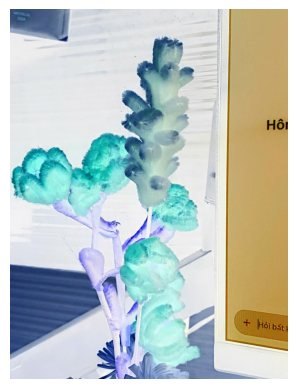

In [13]:
negative_img = 255 - img_rgb

plt.imshow(negative_img)
plt.axis("off")
plt.show()

# Cắt ngưỡng (Thresholding)

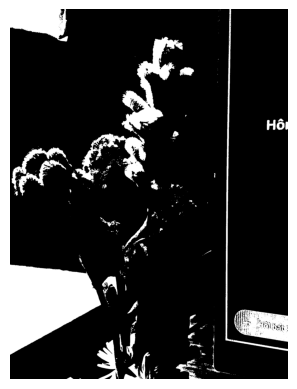

In [15]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
ret, thresh_img = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.imshow(thresh_img, cmap = "gray")
plt.axis("off")
plt.show()

# Lọc tuyến tính (Smoothing & Sharpening)

(np.float64(-0.5), np.float64(1919.5), np.float64(2559.5), np.float64(-0.5))

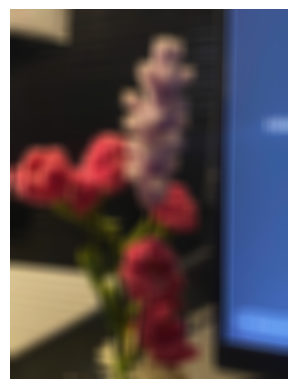

In [ ]:
# Lọc trung bình (Blur)
blur_img = cv2.blur(img_rgb, (99, 99))

plt.imshow(blur_img)
plt.axis("off")

# Lọc Gaussian (Làm mờ tự nhiên)

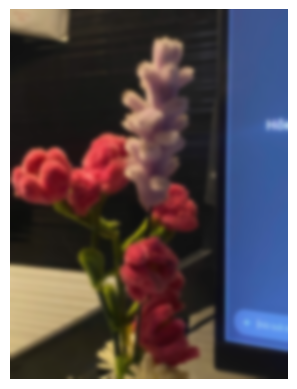

In [ ]:
gaussian_img = cv2.GaussianBlur(img_rgb, (99, 99), 0)
plt.imshow(gaussian_img)
plt.axis('off')
plt.show()

# Làm sắc nét (Sharpening)

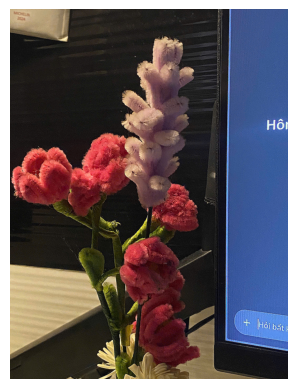

In [ ]:
kernel_sharpening = np.array([[-1,-1,-1], 
                              [-1, 9,-1], 
                              [-1,-1,-1]])
    
sharpening = cv2.filter2D(img_rgb,-1, kernel_sharpening)

plt.imshow(sharpening)
plt.axis("off")
plt.show()

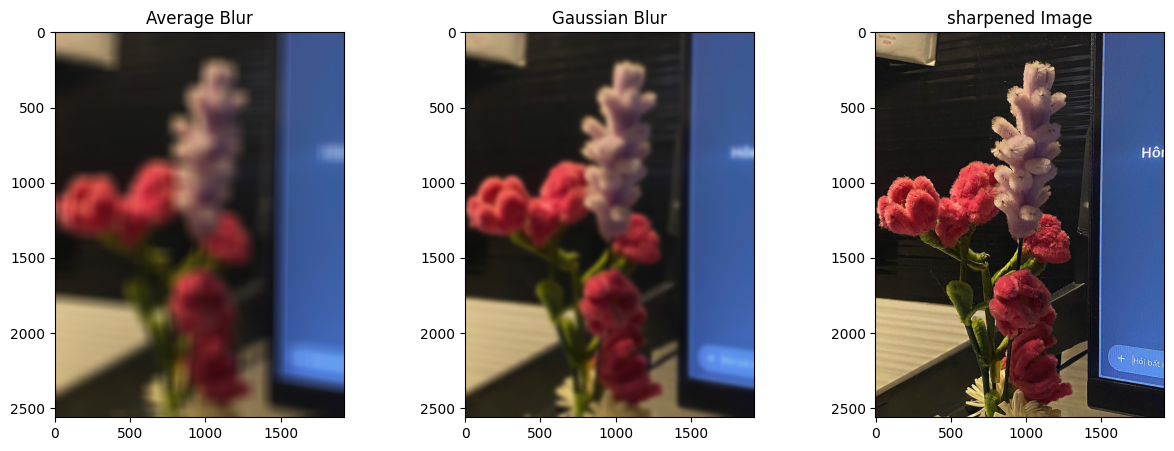

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(blur_img)
plt.title('Average Blur')

plt.subplot(132)
plt.imshow(gaussian_img)
plt.title('Gaussian Blur')

plt.subplot(133)
plt.imshow(sharpening)
plt.title('sharpened Image')

plt.show()

# Bài tập nâng cao

# 1: Phát hiện cạnh: Sử dụng các kernel Sobel, Prewitt
#### Bản chất của phát hiện cạnh là tìm sự thay đổi đột ngột về độ sáng giữa các điểm ảnh liền kề. Toán tử Sobel và Prewitt tính toán đạo hàm (độ dốc sáng) theo hai phương hướng: ngang (X) và dọc (Y).

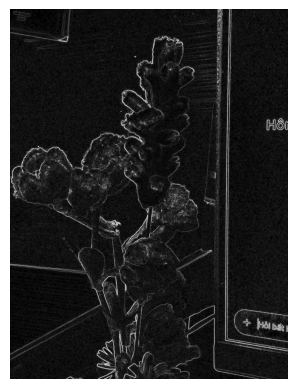

In [ ]:
# 1.a. Toán tử Sobel (dùng hàm OpenCV tích hợp)
# Tính đạo hàm theo hướng X (tìm cạnh dọc)
# cv2.CV_64F: Kiểu dữ liệu số thực để giữ các giá trị đạo hàm âm
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
# Tính đạo hàm theo hướng Y (tìm cạnh ngang)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
# Kết hợp hai hướng bằng cách tính độ lớn (magnitude)
sobel_combined = cv2.magnitude(sobelx, sobely)
# Chuyển đổi về định dạng uint8 để hiển thị được
sobel_final = cv2.convertScaleAbs(sobel_combined)

plt.imshow(sobel_final, cmap="gray")
plt.axis("off")
plt.show()


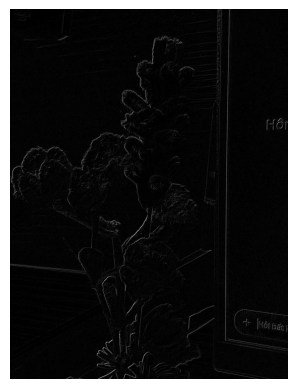

In [ ]:
# 1.b. Toán tử Prewitt (tự định nghĩa kernel và áp dụng)
# Định nghĩa Kernel Prewitt cho hướng X (tìm cạnh dọc)
kernel_prewitt_x = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                             [-1, 0, 1]])
# Định nghĩa Kernel Prewitt cho hướng Y (tìm cạnh ngang)
kernel_prewitt_y = np.array([[-1, -1, -1],
                             [ 0,  0,  0],
                             [ 1,  1,  1]])

# Áp dụng bộ lọc
prewitt_x = cv2.filter2D(gray, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(gray, -1, kernel_prewitt_y)
# Kết hợp hai hướng (cộng đơn giản 50-50)
prewitt_final = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

plt.imshow(prewitt_final,cmap= "gray")
plt.axis("off")
plt.show()

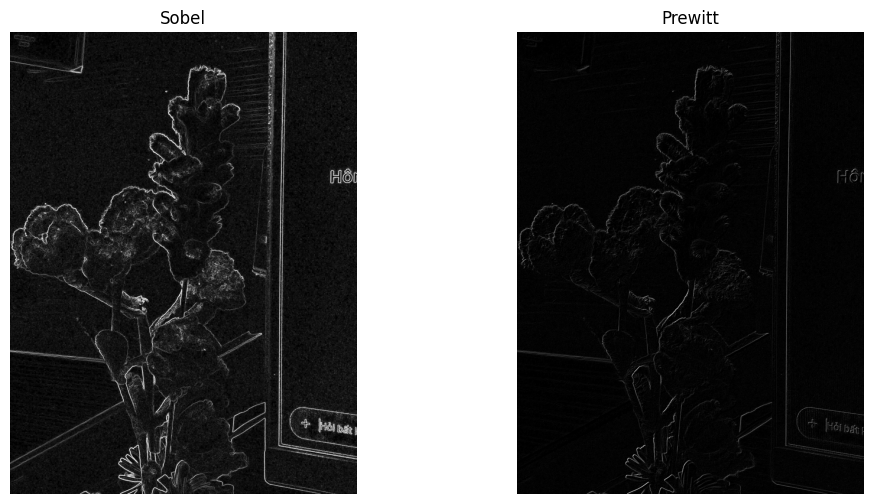

In [ ]:
# Sobel Edge Detection
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# Prewitt Edge Detection
kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewittx = cv2.filter2D(img, -1, kernelx)
prewitty = cv2.filter2D(img, -1, kernely)
prewitt_combined = cv2.addWeighted(cv2.convertScaleAbs(prewittx), 0.5, cv2.convertScaleAbs(prewitty), 0.5, 0)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(sobel_final, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(prewitt_final, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.show()


# 2: Tự thiết kế kernel: Tạo các kernel tùy chỉnh

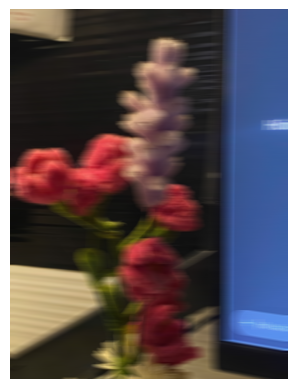

In [ ]:
# 2.c. Kernel làm mờ chuyển động (Motion Blur) ngang
size = 100 
kernel_motion_blur = np.zeros((size, size))
kernel_motion_blur[int((size-1)/2), :] = np.ones(size) 
kernel_motion_blur = kernel_motion_blur / size 
img_motion_blur = cv2.filter2D(img_rgb, -1, kernel_motion_blur)

plt.imshow(img_motion_blur)
plt.axis("off")
plt.show()

In [ ]:
print(kernel_motion_blur)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


# 3: So sánh các loại lọc

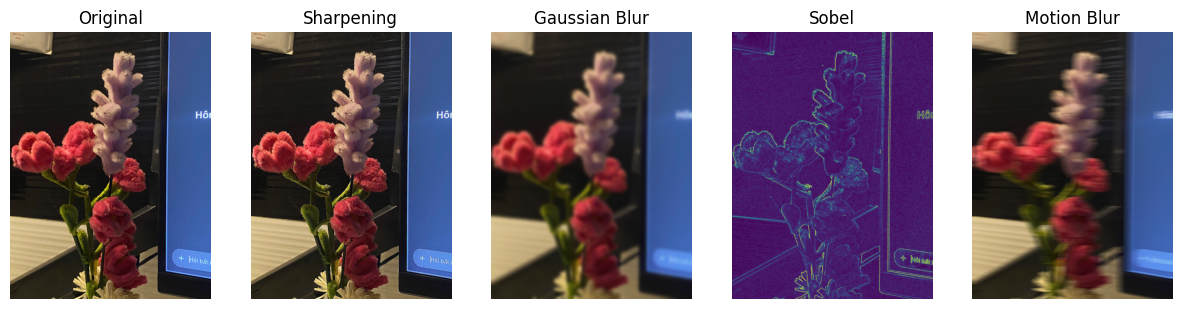

In [ ]:
# so sánh các loại lọc khác nhau

plt.figure(figsize=(15,5))

plt.subplot(151)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(152)
plt.imshow(sharpening)
plt.title('Sharpening')
plt.axis('off')

plt.subplot(153)
plt.imshow(gaussian_img)
plt.title('Gaussian Blur')
plt.axis('off')

plt.subplot(154)
plt.imshow(sobel_final)
plt.title('Sobel')
plt.axis('off')  

plt.subplot(155)
plt.imshow(img_motion_blur)
plt.title('Motion Blur')
plt.axis('off')

plt.show()